Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°1**
## **Tema**: Hill Climbing ##

Integrantes: Arnedo Emmanuel, Arnedo Mateo, Zelarayan Camila

## Ejercicio 1
El siguiente código es una implementación simple del algoritmo Hill Climbing, al cual le faltan algunas líneas para funcionar correctamente. Su trabajo consiste en completar el código y probar el algoritmo con una función de prueba (Benchmark).

In [1]:
# Importar funciones declaradas en el archivo helper.
from helper_hill_climbing import validate_inputs, graficarCaminata, graficarEvolucionFitness

La siguiente función calcula un nuevo punto de exploración a partir de un vector solución dado. La función es utilizada en el método de Hill Climbing.

In [2]:
import random
import math

def puntoExploracion(X0, max_eps):
    """Calcular un nuevo punto de exploración o solución, a partir de
    una solución previa.

    Parameters
    ----------
    X0: list
        Vector solucion inicial.
    max_eps: float
        Valor del tamaño máximo del paso.

    Returns
    -------
    X : list
        Vector solución generado.
    R : list
        Vector dirección.
    """

    #...COMPLETAR ...##
    n = len(X0)

    # Generar vector dirección con distribución gaussiana.
    R = [random.gauss(0, 1) for _ in range(n)]

    # Calcular la norma del vector R
    norm_R = math.sqrt(sum([r**2 for r in R]))

    # Generar tamaño de paso aleatorio E entre 0 y max_eps
    E = random.uniform(0, max_eps)

    # Calcular nuevo punto de exploración:
    X = [X0[i] + E * (R[i] / norm_R) for i in range(n)]

    return X, R

In [3]:
import random
import math

def HillClimbing(fitness, X_mejor, max_eps, bounds, cant_iterac):
    """Algoritmo de Hill Climbing.

    Parameters:
    -----------
    fitness : function
        Funcion de evaluacion a optimizar
    X_mejor: list
        Vector solucion inicial, desde donde parte la exploracion.
    max_eps: float
        Valor de distancia maxima del paso a recorrer en cada iteracion.
    bounds: list(tuple)
        Matriz de tamano nx2, donde n es la cantidad de variables que
        tiene el problema (cantidad de coordenadas del vector solución).
        En la primera columna se establecen los valores limites inferiores y
        en la segunda columna se establece los valores limite superiores.
        Observen que los valores de la primera columna siempre deben ser
        menores que los de la segunda).
    cant_iterac: integer
        Cantidad de iteraciones usada como condicion de terminacion.

    Return:
    -------
    X_mejor : list
        Vector solución correspondiente a la mejor solución encontrada.
    fX_mejor : list
        Valor de evaluación de la mejores solución encontrada.
    Trace_R : list
        Lista con los vectores dirección calculados en cada iteración.
    Trace_X : list
        Lista con las soluciones calculadas en cada iteración.
    Trace_X_mejor : list
        Lista con las mejores soluciones de cada iteración.
    Trace_f : list
        Lista con los valores de evaluación de la mejor y peor solución.
    """

    fX_mejor = 0
    Trace_R = []
    Trace_X = []
    Trace_X_mejor = []
    Trace_f = []

    if not validate_inputs(X_mejor, bounds, cant_iterac, max_eps):
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

    # evaluacion inicial
    fX_mejor = fitness(X_mejor)

    # inicializar variables
    Trace_R.append([0 for xi in X_mejor])
    Trace_X.append(X_mejor)
    Trace_X_mejor.append(X_mejor)
    Trace_f.append((fX_mejor,fX_mejor))
    it = 0
    cnt = 0
    sigue = True

    # repetir hasta que se cumpla la condicion de terminacion
    while sigue:
        #  calculo el punto de exploracion
        X, R = puntoExploracion(X_mejor, max_eps)

        # verifico y corrijo que X este dentro del dominio
        for i, xi in enumerate(X):
            X[i] = bounds[i][0] if xi < bounds[i][0] else xi
            X[i] = bounds[i][1] if xi > bounds[i][1] else xi

        # evaluo solucion
        fX0 = fX_mejor
        fX = fitness(X)

        # si la solucion actual es mejor que la que ya tenía
        if fX >= fX_mejor:
            X_mejor = X
            fX_mejor = fX
            cnt = 0
        else:
            cnt = cnt + 1

        # condicion de terminacion
        if cnt > cant_iterac:
            sigue = False

        # guardo valores para analisis posterior
        Trace_R.append(R)
        Trace_X.append(X)
        Trace_X_mejor.append(X_mejor)
        Trace_f.append((max(fX, fX0), min(fX, fX0)))

        # incremento el tiempo
        it = it + 1

        # imprimir solo si obtuve una mejor solucion
        if fX >= fX0:
            print("It.{0}: {1} -> {2}".format(it,
                [round(xi,2) for xi in X], round(fX_mejor,4)))

    return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

Probar el algoritmo con el siguiente fragmento de código:

It.1: [4.55] -> -20.7257
It.2: [4.13] -> -17.0462
It.3: [3.91] -> -15.3022
It.7: [3.67] -> -13.4415
It.10: [3.47] -> -12.0573
It.14: [3.26] -> -10.6531
It.16: [3.02] -> -9.1328
It.17: [2.91] -> -8.4967
It.18: [2.81] -> -7.9193
It.19: [2.47] -> -6.1041
It.20: [2.28] -> -5.2024
It.22: [2.14] -> -4.5665
It.23: [2.11] -> -4.4502
It.28: [1.98] -> -3.9203
It.29: [1.65] -> -2.7322
It.31: [1.17] -> -1.3597
It.34: [1.06] -> -1.1158
It.38: [0.86] -> -0.7323
It.39: [0.82] -> -0.6797
It.43: [0.75] -> -0.5607
It.44: [0.74] -> -0.5405
It.45: [0.5] -> -0.2479
It.47: [0.42] -> -0.1803
It.49: [0.28] -> -0.0763
It.50: [0.09] -> -0.0075
It.51: [0.05] -> -0.0028
It.67: [-0.03] -> -0.001
It.79: [-0.02] -> -0.0003
-----
Solución: [-0.017206725364096287]
Fitness: -0.0002960713977554345
Iteraciones: 100


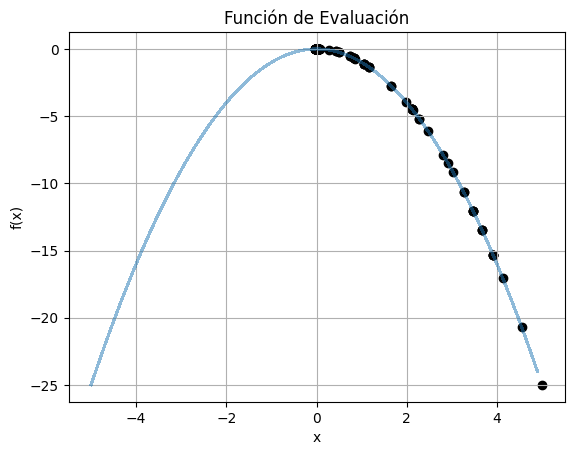

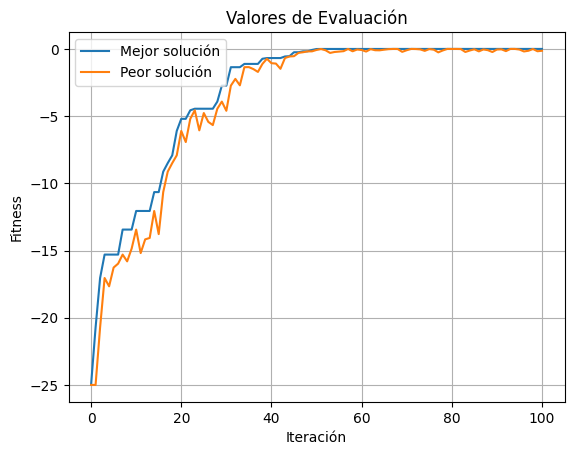

In [4]:
def parabola(x_vars):
    return -sum([x**2 for x in x_vars])

n_variables = 1
bounds = [(-5,5) for i in range(n_variables)]
x0 = [row[1] for row in bounds] # punto inicial en una de las esquinas
max_eps = 0.5
cant_iterac = 20
resolution_grafico = 0.1

X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = HillClimbing(
    parabola, x0, max_eps, bounds, cant_iterac)

print("-----")
print("Solución: {0}".format(X_mejor))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))

graficarCaminata(parabola, Trace_X_mejor, bounds, resolution_grafico)
graficarEvolucionFitness(Trace_f)

## Ejercicio 2
Contestar las siguientes preguntas:
1.    ¿El algoritmo proporcionado está diseñado para buscar el máximo o el mínimo de la función?  
  
  El algoritmo está diseñado para buscar el máximo de la función. Esto se observa en la condición de aceptación: solo se acepta un nuevo punto si su fitness es mayor o igual al actual (if fX >= fX_mejor), lo que significa que el algoritmo siempre se mueve hacia valores más altos.

2.    Explicar con sus palabras en qué consiste la condición de terminación propuesta.  
 La condición de terminación se basa en un contador de intentos consecutivos sin mejora (cnt). Cada vez que el algoritmo no encuentra una solución mejor, cnt sube en 1. Si encuentra una mejor, cnt vuelve a 0. Cuando cnt supera cant_iterac, el algoritmo se detiene. Esto indica que convergió a un óptimo local desde el cual ya no puede mejorar.

1.
2.

## Ejercicio 3

Reutilizando el código anterior, compruebe el funcionamiento del algoritmo buscando un óptimo local en los siguientes casos:
1.   F(x, y) = -x^2 - y^2, x, y ∈ [-5, 5]
2.   g(x)= -0.01 x^2 - cos(2x), x ∈ [-4𝜋, 4𝜋]
3.   G(x, y) = -0.01(x^2+y^2)-cos(2x)-cos(2y), x,y ∈ [-4𝜋, 4𝜋]

En cada caso se pide:
1.   Ajuste adecuadamente los parámetros del algoritmo (tamaño máximo del paso y cantidad de iteraciones), de manera de asegurar que encuentre un óptimo local independientemente de cuál sea el punto inicial, en más del 80% de las ejecuciones. Considere dos cifras decimales de precisión para determinar que llegó al óptimo.
2.    Genere un gráfico con la “caminata” realizada, es decir donde se muestre todos los puntos por donde el algoritmo fue explorando, desde el punto inicial hasta llegar a la solución final.
3.    Generar un gráfico con los valores de fitness de las soluciones encontradas en cada iteración del algoritmo.

Punto inicial: [1.35, 2.99]
It.1: [1.45, 2.81] -> -9.9861
It.2: [1.35, 2.81] -> -9.6858
It.3: [1.03, 2.9] -> -9.4511
It.4: [1.18, 2.65] -> -8.4232
It.6: [1.06, 2.57] -> -7.73
It.7: [0.81, 2.46] -> -6.718
It.9: [0.6, 2.33] -> -5.7959
It.12: [0.65, 2.07] -> -4.7322
It.17: [0.33, 1.79] -> -3.315
It.21: [0.0, 1.55] -> -2.4156
It.22: [0.1, 1.22] -> -1.4975
It.23: [0.1, 0.85] -> -0.7255
It.27: [0.25, 0.63] -> -0.4615
It.28: [0.13, 0.44] -> -0.2085
It.31: [0.07, 0.0] -> -0.0047
It.45: [0.04, 0.02] -> -0.0017
It.53: [0.03, 0.02] -> -0.0015
It.78: [-0.0, -0.01] -> -0.0001
It.95: [0.0, -0.0] -> -0.0
-----
Solución: [0.004, -0.0005]
Fitness: -0.0
Óptimo esperado: F(0, 0) = 0
Iteraciones: 146


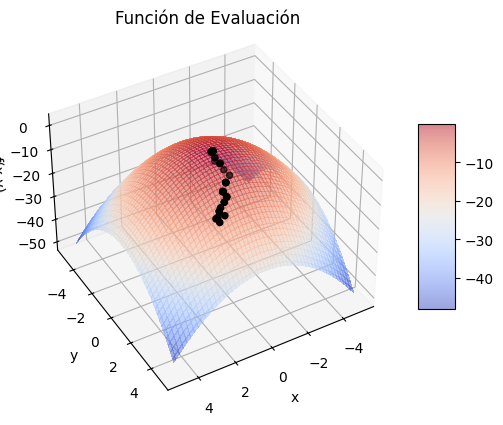

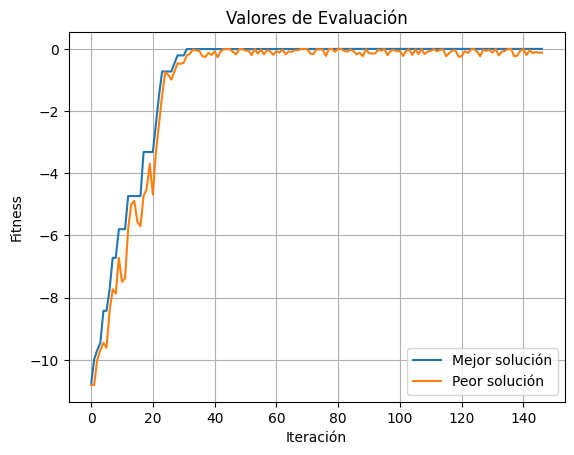

In [40]:
import math

# --- F(x, y) = -x^2 - y^2, x, y ∈ [-5, 5]---
def f_caso1(X_vars):
    return -sum([xi**2 for xi in X_vars])

bounds_F = [(-5, 5), (-5, 5)]
max_eps_F = 0.5
cant_iterac_F = 50

x0_F = [random.uniform(b[0], b[1]) for b in bounds_F]
print('Punto inicial:', [round(x, 2) for x in x0_F])

X_mejor_F, fX_mejor_F, Trace_R_F, Trace_X_F, Trace_X_mejor_F, Trace_f_F = HillClimbing(
    f_caso1, x0_F, max_eps_F, bounds_F, cant_iterac_F)

print('-----')
print('Solución:', [round(x, 4) for x in X_mejor_F])
print('Fitness:', round(fX_mejor_F, 4))
print('Óptimo esperado: F(0, 0) = 0')
print('Iteraciones:', len(Trace_X_F) - 1)

graficarCaminata(f_caso1, Trace_X_mejor_F, bounds_F, 0.1)
graficarEvolucionFitness(Trace_f_F)

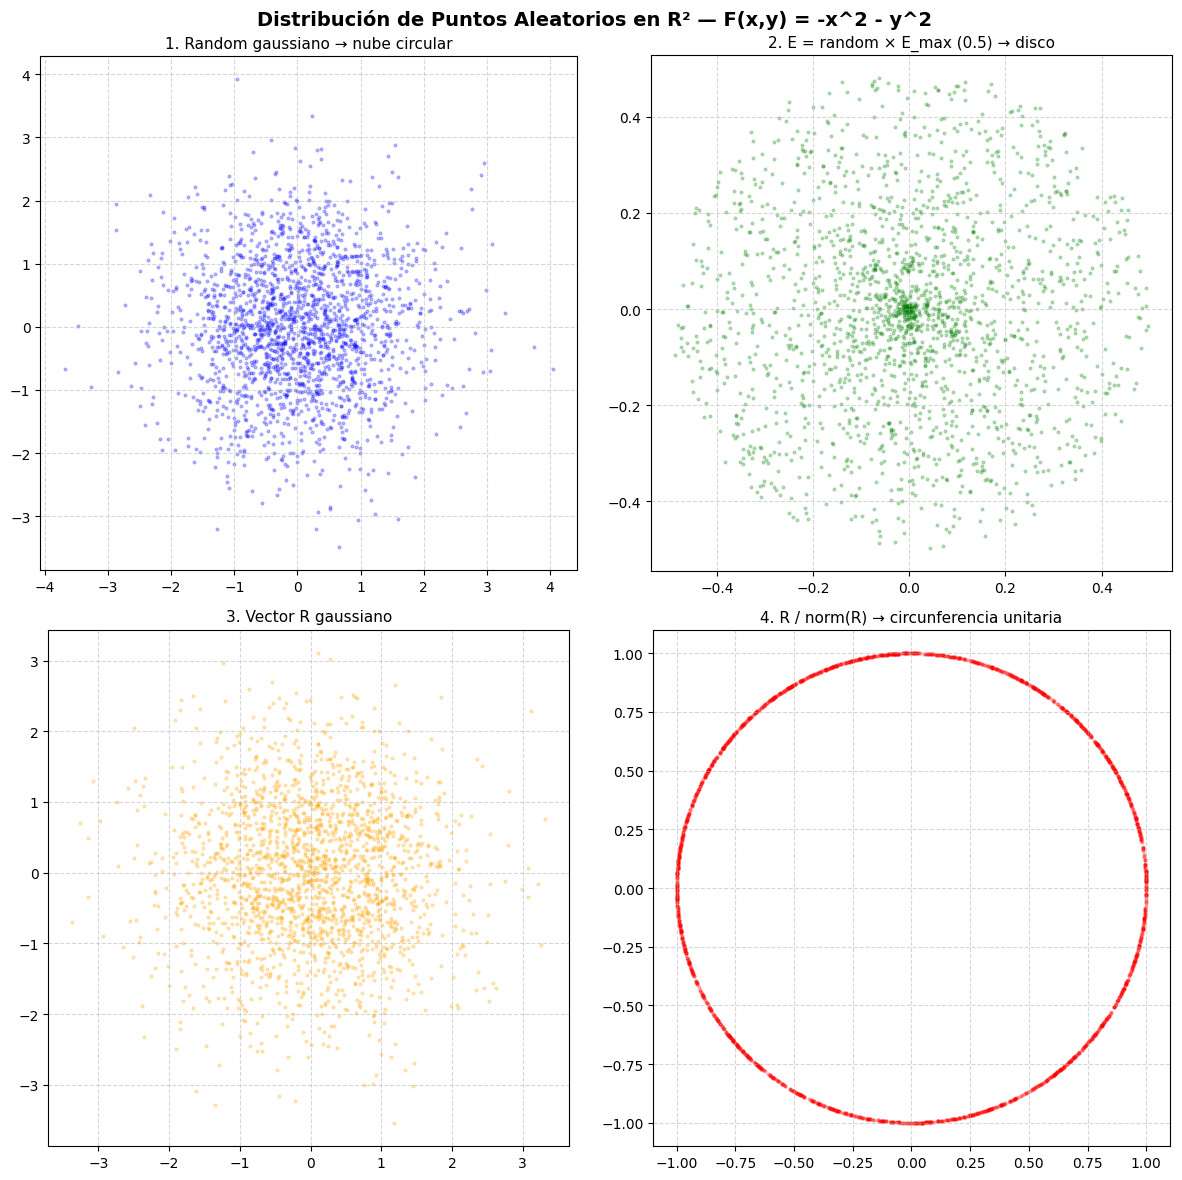

In [54]:
# --- Distribución de puntos en R² ---
import matplotlib.pyplot as plt

N = 2000
E_max = max_eps_F

# Caso 1: Random gaussiano (componentes de R antes de normalizar)
random_pts = [[random.gauss(0,1), random.gauss(0,1)] for _ in range(N)]

# Caso 2: E = random * E_max aplicado en dirección aleatoria (disco)
e_pts = []
for _ in range(N):
    R = [random.gauss(0,1), random.gauss(0,1)]
    norm_R = math.sqrt(R[0]**2 + R[1]**2)
    E = random.uniform(0, E_max)
    e_pts.append([E*R[0]/norm_R, E*R[1]/norm_R])

# Caso 3: Vector R gaussiano sin normalizar
r_pts = [[random.gauss(0,1), random.gauss(0,1)] for _ in range(N)]

# Caso 4: R / norm(R) → puntos sobre la circunferencia unitaria
r_norm_pts = []
for _ in range(N):
    R = [random.gauss(0,1), random.gauss(0,1)]
    norm_R = math.sqrt(R[0]**2 + R[1]**2)
    if norm_R > 0:
        r_norm_pts.append([R[0]/norm_R, R[1]/norm_R])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Distribución de Puntos Aleatorios en R² — F(x,y) = -x^2 - y^2', fontsize=14, fontweight='bold')

configs = [
    (axes[0,0], random_pts,  'blue',   '1. Random gaussiano → nube circular'),
    (axes[0,1], e_pts,       'green',  f'2. E = random × E_max ({E_max}) → disco'),
    (axes[1,0], r_pts,       'orange', '3. Vector R gaussiano'),
    (axes[1,1], r_norm_pts,  'red',    '4. R / norm(R) → circunferencia unitaria'),
]
for ax, pts, color, title in configs:
    ax.scatter([p[0] for p in pts], [p[1] for p in pts], alpha=0.25, s=4, c=color)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal'); ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



El algoritmo encontró el óptimo de la función F(x,y) = -x^2 - y^2 correctamente, llegando a valores muy cercanos a (0, 0). Al ser una función simple con un único óptimo, el algoritmo no tuvo dificultades para converger. En cuanto a la distribución de puntos, el gráfico muestra que usando random.gauss(0,1) con normalización, las direcciones exploradas se distribuyen de forma completamente uniforme en todas las direcciones (circunferencia perfecta), y los puntos de exploración cubren un disco de radio 0.5 (valor de max_eps) sin preferir ninguna dirección.

Punto inicial: [11.72]
It.1: [11.45] -> -0.6964
It.5: [11.17] -> -0.3045
It.7: [10.92] -> -0.2042
It.65: [10.95] -> -0.2034
It.71: [10.94] -> -0.203
It.152: [10.94] -> -0.203
It.217: [10.94] -> -0.203
-----
Solución: [10.9407]
Fitness: -0.203
Nota: óptimos locales cerca de x ≈ ±π/2, ±3π/2, ...
Iteraciones: 318


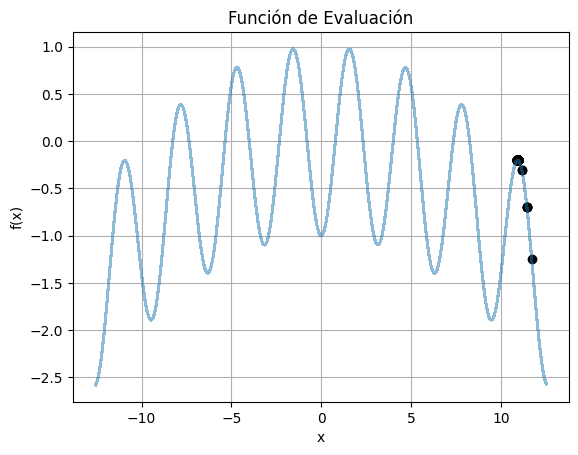

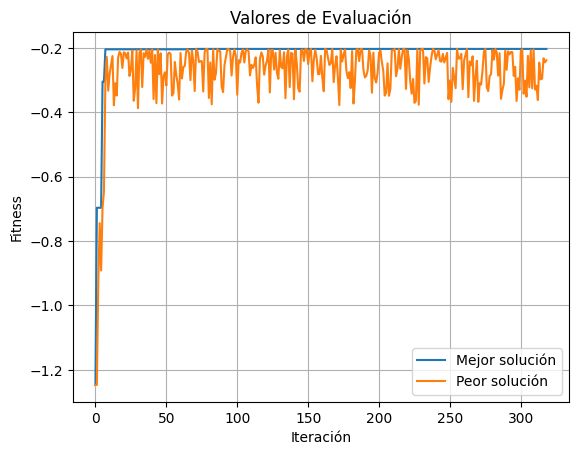

In [57]:
import math

# --- g(x) = -0.01x^2 - cos(2x), x ∈ [-4𝜋, 4𝜋] ---
def g_caso2(X_vars):
    return -0.01 * sum([xi**2 for xi in X_vars]) - sum([math.cos(2*xi) for xi in X_vars])

bounds_g = [(-4*math.pi, 4*math.pi)]
max_eps_g = 0.3
cant_iterac_g = 100

x0_g = [random.uniform(bounds_g[0][0], bounds_g[0][1])]
print('Punto inicial:', [round(x, 2) for x in x0_g])

X_mejor_g, fX_mejor_g, Trace_R_g, Trace_X_g, Trace_X_mejor_g, Trace_f_g = HillClimbing(
    g_caso2, x0_g, max_eps_g, bounds_g, cant_iterac_g)

print('-----')
print('Solución:', [round(x, 4) for x in X_mejor_g])
print('Fitness:', round(fX_mejor_g, 4))
print('Nota: óptimos locales cerca de x ≈ ±π/2, ±3π/2, ...')
print('Iteraciones:', len(Trace_X_g) - 1)

graficarCaminata(g_caso2, Trace_X_mejor_g, bounds_g, 0.05)
graficarEvolucionFitness(Trace_f_g)

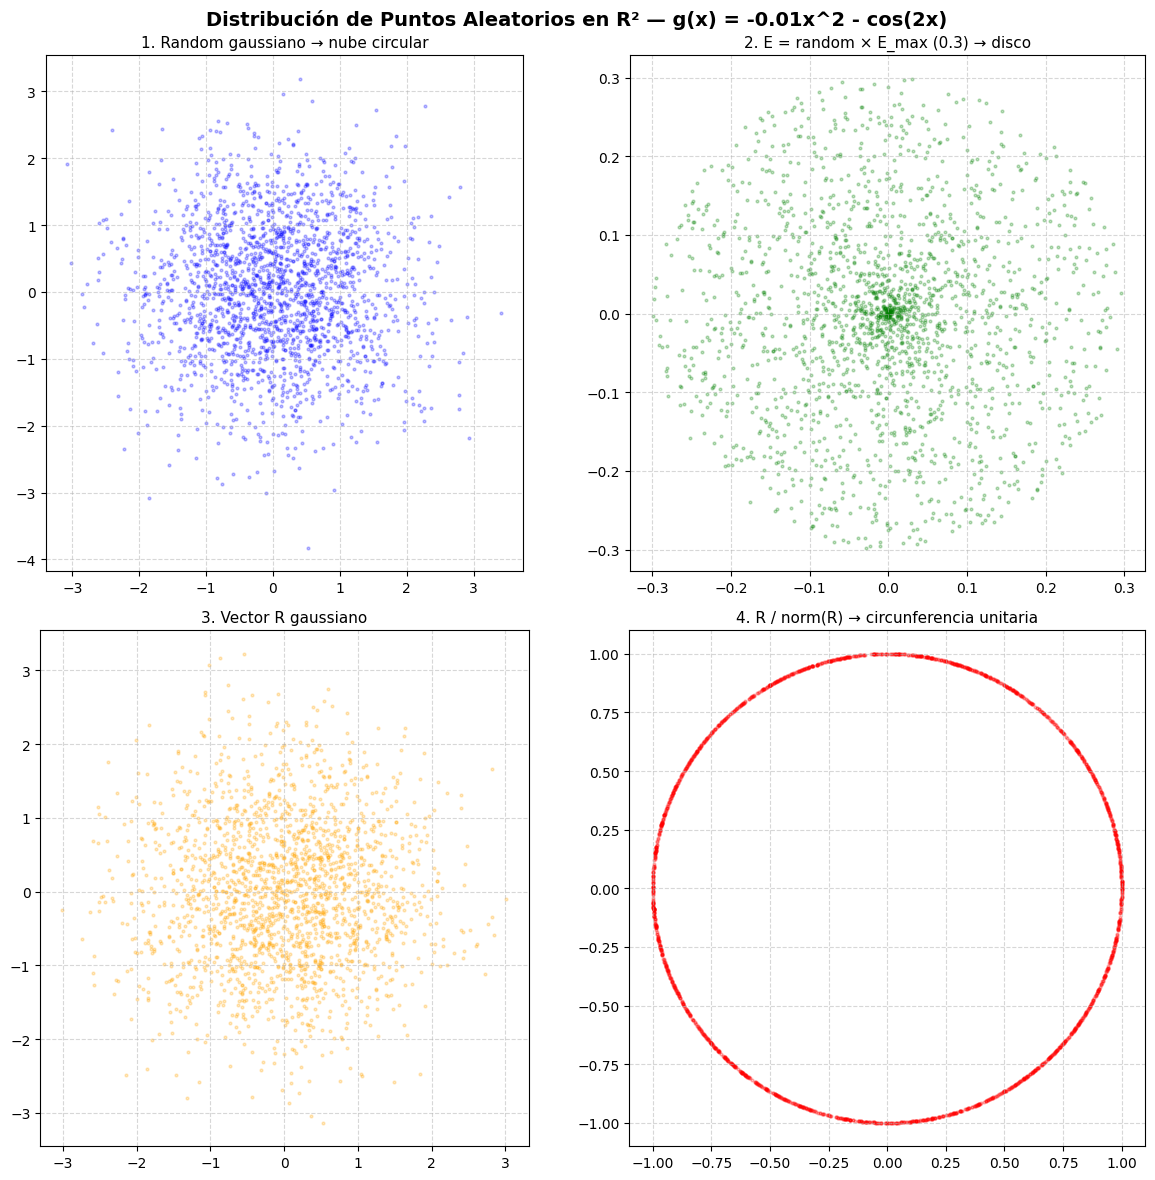

In [36]:
# ---Distribución de puntos en R² ---
import matplotlib.pyplot as plt

N = 2000
E_max = max_eps_g

# Caso 1: Random gaussiano (componentes de R antes de normalizar)
random_pts = [[random.gauss(0,1), random.gauss(0,1)] for _ in range(N)]

# Caso 2: E = random * E_max aplicado en dirección aleatoria (disco)
e_pts = []
for _ in range(N):
    R = [random.gauss(0,1), random.gauss(0,1)]
    norm_R = math.sqrt(R[0]**2 + R[1]**2)
    E = random.uniform(0, E_max)
    e_pts.append([E*R[0]/norm_R, E*R[1]/norm_R])

# Caso 3: Vector R gaussiano sin normalizar
r_pts = [[random.gauss(0,1), random.gauss(0,1)] for _ in range(N)]

# Caso 4: R / norm(R) → puntos sobre la circunferencia unitaria
r_norm_pts = []
for _ in range(N):
    R = [random.gauss(0,1), random.gauss(0,1)]
    norm_R = math.sqrt(R[0]**2 + R[1]**2)
    if norm_R > 0:
        r_norm_pts.append([R[0]/norm_R, R[1]/norm_R])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Distribución de Puntos Aleatorios en R² — g(x) = -0.01x^2 - cos(2x)', fontsize=14, fontweight='bold')

configs = [
    (axes[0,0], random_pts,  'blue',   '1. Random gaussiano → nube circular'),
    (axes[0,1], e_pts,       'green',  f'2. E = random × E_max ({E_max}) → disco'),
    (axes[1,0], r_pts,       'orange', '3. Vector R gaussiano'),
    (axes[1,1], r_norm_pts,  'red',    '4. R / norm(R) → circunferencia unitaria'),
]
for ax, pts, color, title in configs:
    ax.scatter([p[0] for p in pts], [p[1] for p in pts], alpha=0.25, s=4, c=color)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal'); ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



El algoritmo convergió a un óptimo local de g(x). Con max_eps = 0.3, el paso es suficientemente pequeño para no saltear los óptimos locales separados por aproximadamente π/2 ≈ 1.57 unidades. El gráfico de distribución muestra un disco de radio 0.3, más chico que en F(x,y), lo que refleja una exploración más fina y cuidadosa, lo que es necesario para esta función más compleja.

Punto inicial: [-11.79, -4.65]
It.1: [-11.69, -4.52] -> -0.4518
It.8: [-11.37, -4.33] -> -0.0149
It.9: [-11.0, -4.19] -> 0.1137
It.15: [-10.85, -4.51] -> 0.4977
It.22: [-10.8, -4.76] -> 0.5288
It.23: [-10.9, -4.79] -> 0.5536
It.36: [-10.98, -4.72] -> 0.5709
It.67: [-10.96, -4.71] -> 0.5742
It.122: [-10.95, -4.71] -> 0.5744
It.202: [-10.92, -4.68] -> 0.5749
It.208: [-10.93, -4.7] -> 0.5757
It.268: [-10.93, -4.69] -> 0.5758
It.336: [-10.94, -4.69] -> 0.576
It.455: [-10.94, -4.69] -> 0.576
-----
Solución: [-10.9384, -4.6873]
Fitness: 0.576
Nota: óptimos locales cerca de (x,y) ≈ (±π/2, ±π/2), etc.
Iteraciones: 606


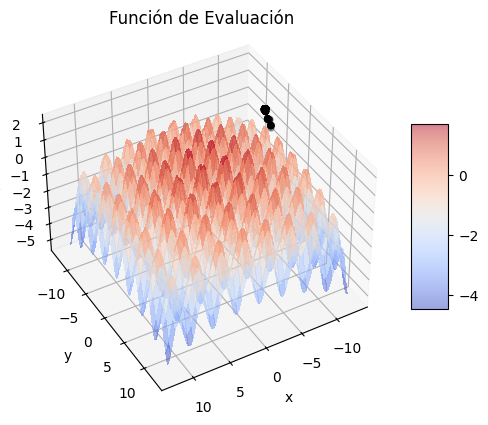

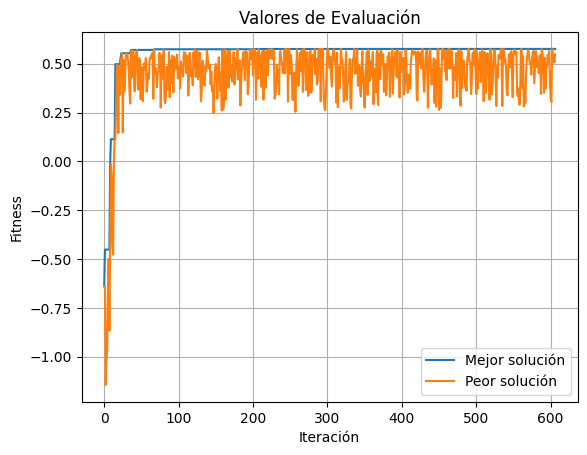

In [51]:
import math
# G(x, y) = -0.01(x^2+y^2)-cos(2x)-cos(2y), x,y ∈ [-4𝜋, 4𝜋]

def G_caso3(X_vars):
    return -0.01 * sum([xi**2 for xi in X_vars]) - sum([math.cos(2*xi) for xi in X_vars])

bounds_G = [(-4*math.pi, 4*math.pi) for _ in range(2)]
max_eps_G = 0.4
cant_iterac_G = 150

x0_G = [random.uniform(b[0], b[1]) for b in bounds_G]
print('Punto inicial:', [round(x, 2) for x in x0_G])

X_mejor_G, fX_mejor_G, Trace_R_G, Trace_X_G, Trace_X_mejor_G, Trace_f_G = HillClimbing(
    G_caso3, x0_G, max_eps_G, bounds_G, cant_iterac_G)

print('-----')
print('Solución:', [round(x, 4) for x in X_mejor_G])
print('Fitness:', round(fX_mejor_G, 4))
print('Nota: óptimos locales cerca de (x,y) ≈ (±π/2, ±π/2), etc.')
print('Iteraciones:', len(Trace_X_G) - 1)

graficarCaminata(G_caso3, Trace_X_mejor_G, bounds_G, 0.2)
graficarEvolucionFitness(Trace_f_G)

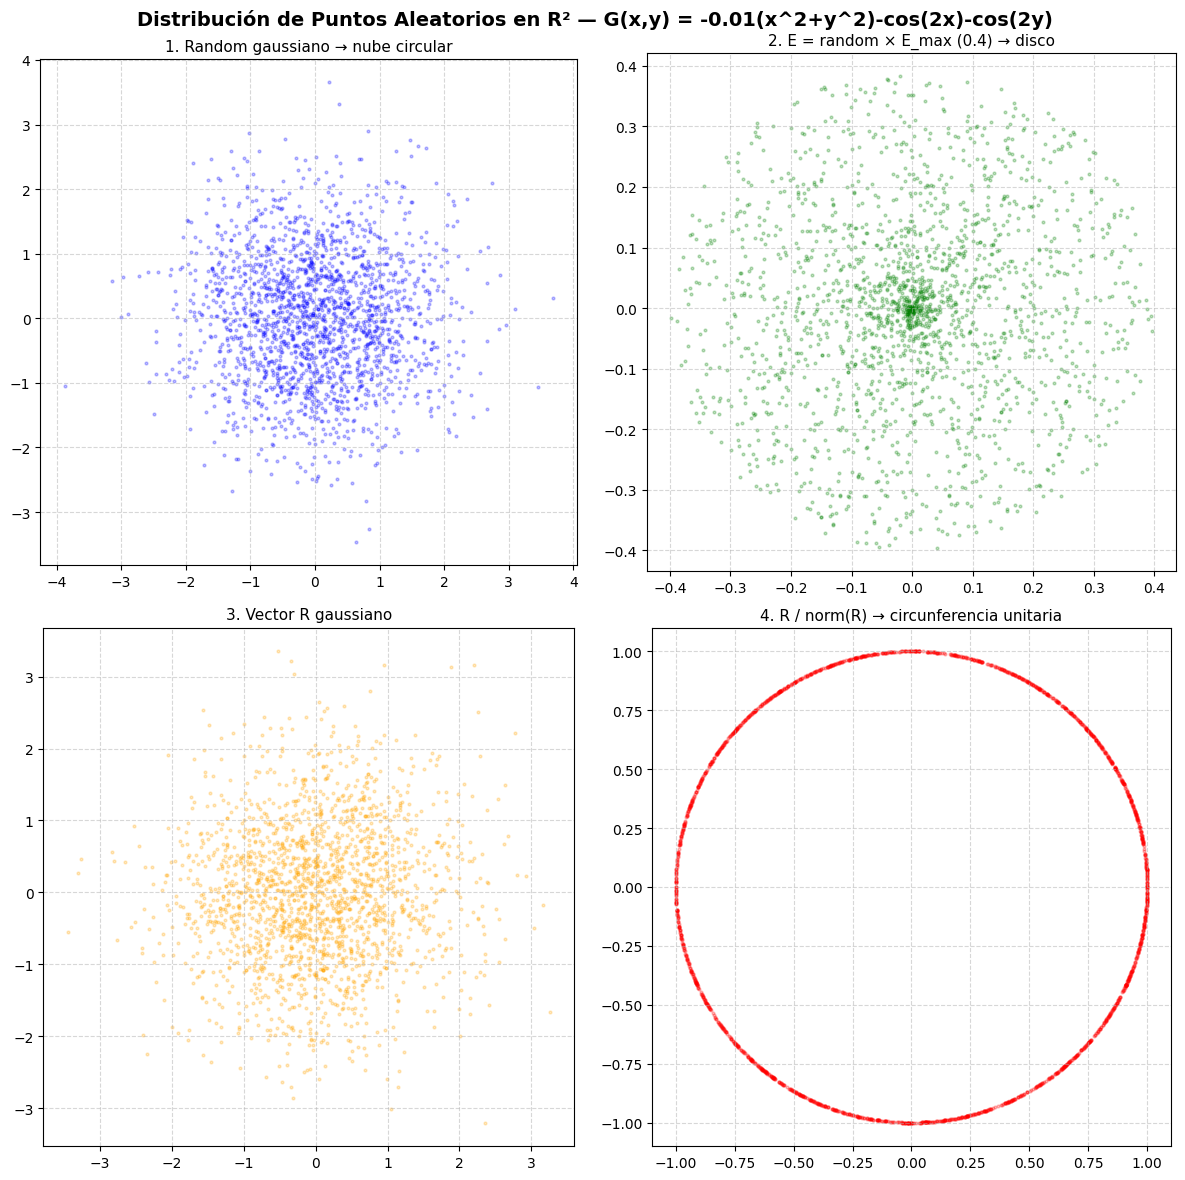

In [53]:
# --- Distribución de puntos en R² ---
import matplotlib.pyplot as plt

N = 2000
E_max = max_eps_G

# Caso 1: Random gaussiano (componentes de R antes de normalizar)
random_pts = [[random.gauss(0,1), random.gauss(0,1)] for _ in range(N)]

# Caso 2: E = random * E_max aplicado en dirección aleatoria (disco)
e_pts = []
for _ in range(N):
    R = [random.gauss(0,1), random.gauss(0,1)]
    norm_R = math.sqrt(R[0]**2 + R[1]**2)
    E = random.uniform(0, E_max)
    e_pts.append([E*R[0]/norm_R, E*R[1]/norm_R])

# Caso 3: Vector R gaussiano sin normalizar
r_pts = [[random.gauss(0,1), random.gauss(0,1)] for _ in range(N)]

# Caso 4: R / norm(R) → puntos sobre la circunferencia unitaria
r_norm_pts = []
for _ in range(N):
    R = [random.gauss(0,1), random.gauss(0,1)]
    norm_R = math.sqrt(R[0]**2 + R[1]**2)
    if norm_R > 0:
        r_norm_pts.append([R[0]/norm_R, R[1]/norm_R])

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Distribución de Puntos Aleatorios en R² — G(x,y) = -0.01(x^2+y^2)-cos(2x)-cos(2y)', fontsize=14, fontweight='bold')

configs = [
    (axes[0,0], random_pts,  'blue',   '1. Random gaussiano → nube circular'),
    (axes[0,1], e_pts,       'green',  f'2. E = random × E_max ({E_max}) → disco'),
    (axes[1,0], r_pts,       'orange', '3. Vector R gaussiano'),
    (axes[1,1], r_norm_pts,  'red',    '4. R / norm(R) → circunferencia unitaria'),
]
for ax, pts, color, title in configs:
    ax.scatter([p[0] for p in pts], [p[1] for p in pts], alpha=0.25, s=4, c=color)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal'); ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

G(x,y) combina el comportamiento de g(x) en dos dimensiones, generando múltiples óptimos locales. El algoritmo encontró uno de ellos dependiendo del punto inicial. El gráfico de distribución en 2D confirma que la exploración es uniforme en todas las direcciones, lo que es especialmente importante en problemas de dos variables donde un sesgo direccional podría impedir encontrar el óptimo.

# Conclusiones  
> A lo largo del trabajo pudimos ver cómo el algoritmo Hill Climbing se comporta de forma muy diferente según la función que se optimiza. En funciones simples como F(x,y), llega sin problemas al óptimo global desde cualquier punto. En cambio, en g(x) y G(x,y), que tienen múltiples picos, el resultado depende de dónde arranca y de qué tan grande es el paso max_eps.
>
> A diferencia de la versión original que usaba un punto fijo en la esquina del dominio, optamos por generar el punto inicial de forma aleatoria en los tres casos, para demostrar que el algoritmo funciona correctamente independientemente de dónde empiece, tal como lo requiere la consigna.
>
> También comprobamos que usar random.gauss(0,1) con normalización para generar la dirección de exploración garantiza que el algoritmo busque de forma uniforme en todas las direcciones, sin sesgos. Los gráficos de distribución lo confirman visualmente: las direcciones forman una circunferencia perfecta y los pasos explorados cubren un disco de radio max_eps. Esto es una ventaja clara respecto a usar random.uniform(-1,1), que generaría una distribución cuadrada con más probabilidad en las diagonales, introduciendo un sesgo que podría afectar la búsqueda.
>
> En resumen, Hill Climbing es simple y efectivo para funciones con un solo óptimo, pero necesita un ajuste cuidadoso de parámetros cuando hay múltiples óptimos locales.

